In [ ]:
import os, glob, zipfile

ZIP_PATH = "/content/archive.zip"
ROOT = "/content/fashion"

if not glob.glob(f"{ROOT}/**/styles.csv", recursive=True):
    assert os.path.exists(ZIP_PATH), f"Zip not found at {ZIP_PATH}"
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(ROOT)

DATA = os.path.dirname(glob.glob(f"{ROOT}/**/styles.csv", recursive=True)[0])
print("DATA =", DATA)
print("images:", len(os.listdir(f"{DATA}/images")))

DATA = /content/fashion
images: 44441


In [ ]:
import os, numpy as np, pandas as pd, torch, torch.nn as nn, torchvision
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from torchvision import transforms as T

N_ITEMS = 5000          # number of products used (more = better, slower)
MIN_PER_TYPE = 30       # drop very rare article types
AE_EPOCHS = 20
K = 10                  # recommend the top-10
SEED = 0

# DATA is set in the Colab setup cell above
device = "cuda" if torch.cuda.is_available() else "cpu"
np.random.seed(SEED); torch.manual_seed(SEED)
print("Device:", device)

Device: cuda


In [ ]:
df = pd.read_csv(f"{DATA}/styles.csv", on_bad_lines="skip").dropna(subset=["articleType"])
df = df[[os.path.exists(f"{DATA}/images/{i}.jpg") for i in df["id"]]]
counts = df["articleType"].value_counts()
df = df[df["articleType"].isin(counts[counts >= MIN_PER_TYPE].index)]
df = df.sample(min(N_ITEMS, len(df)), random_state=SEED).reset_index(drop=True)

ids = df["id"].values
labels = pd.factorize(df["articleType"])[0]
print(f"{len(df)} products, {df['articleType'].nunique()} article types")
df["articleType"].value_counts().head(10)

5000 products, 83 article types


,count
articleType,
Tshirts,816
Shirts,381
Casual Shoes,343
Watches,272
Handbags,231
Sports Shoes,224
Kurtas,220
Tops,203
Heels,141


In [ ]:
resnet = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Identity()                      # output = 2048-number feature vector
resnet = resnet.eval().to(device)
prep = T.Compose([T.Resize((224, 224)), T.ToTensor(),
                  T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

resnet_feats, small_imgs = [], []
for i in tqdm(range(0, len(ids), 64), desc="Loading images"):
    imgs = [Image.open(f"{DATA}/images/{p}.jpg").convert("RGB") for p in ids[i:i + 64]]
    with torch.no_grad():
        resnet_feats.append(resnet(torch.stack([prep(im) for im in imgs]).to(device)).cpu().numpy())
    small_imgs.append(np.stack([np.asarray(im.resize((64, 64))) for im in imgs]))

resnet_feats = np.vstack(resnet_feats)
small_imgs = torch.tensor(np.vstack(small_imgs)).permute(0, 3, 1, 2).float() / 255   # (N, 3, 64, 64)
print(resnet_feats.shape, small_imgs.shape)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]
Loading images: 100%|██████████| 79/79 [00:26<00:00,  3.00it/s]


(5000, 2048) torch.Size([5000, 3, 64, 64])


In [ ]:
train_idx, test_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=SEED)
print("Train:", len(train_idx), "| Test:", len(test_idx))

Train: 4000 | Test: 1000


In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self, latent=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),       # 64 -> 32
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),      # 32 -> 16
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),     # 16 -> 8
            nn.Flatten(), nn.Linear(128 * 8 * 8, latent))
        self.decoder_fc = nn.Linear(latent, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid())

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(self.decoder_fc(z).view(-1, 128, 8, 8)), z

ae = AutoEncoder().to(device)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)

for epoch in range(AE_EPOCHS):
    perm = np.random.permutation(train_idx)
    total = 0
    for i in range(0, len(perm), 128):
        x = small_imgs[perm[i:i + 128]].to(device)
        loss = nn.functional.mse_loss(ae(x)[0], x)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * len(x)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{AE_EPOCHS}  reconstruction loss {total / len(perm):.4f}")

ae.eval()
with torch.no_grad():
    ae_feats = ae(small_imgs.to(device))[1].cpu().numpy()

Epoch 5/20  reconstruction loss 0.0212
Epoch 10/20  reconstruction loss 0.0119
Epoch 15/20  reconstruction loss 0.0097
Epoch 20/20  reconstruction loss 0.0072


In [ ]:
def evaluate(emb, y, k=K):
    nn_model = NearestNeighbors(n_neighbors=k + 1, metric="cosine").fit(emb)
    _, idx = nn_model.kneighbors(emb)
    precisions, avg_precisions = [], []
    for q in range(len(emb)):
        neighbours = [j for j in idx[q] if j != q][:k]             # remove the query itself
        hits = np.array([y[j] == y[q] for j in neighbours])
        total_relevant = (y == y[q]).sum() - 1
        if total_relevant == 0:
            continue
        precisions.append(hits.mean())                             # Precision@k
        running = np.cumsum(hits) / np.arange(1, k + 1)            # precision after each rank
        avg_precisions.append((running * hits).sum() / min(k, total_relevant))   # AP@k
    return np.mean(precisions), np.mean(avg_precisions)

methods = {
    "Random": np.random.randn(len(df), 64),
    "Autoencoder (from scratch)": ae_feats,
    "ResNet-50 (pretrained)": resnet_feats,
}
rows = []
for name, emb in methods.items():
    p, m = evaluate(emb[test_idx], labels[test_idx])
    rows.append({"Method": name, f"Precision@{K}": round(p, 4), f"MAP@{K}": round(m, 4)})

results = pd.DataFrame(rows)
results.to_csv("results.csv", index=False)
results

,Method,Precision@10,MAP@10
0,Random,0.0565,0.0197
1,Autoencoder (from scratch),0.4334,0.3690
2,ResNet-50 (pretrained),0.5819,0.5316


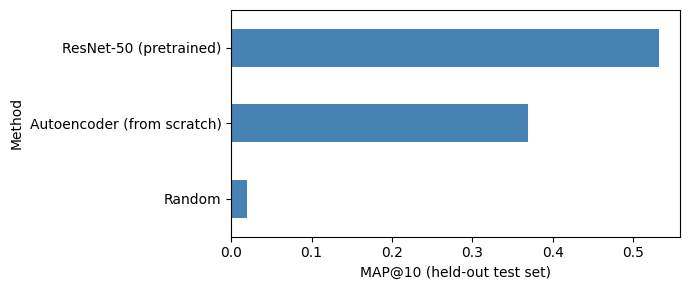

In [ ]:
results.set_index("Method")[f"MAP@{K}"].plot.barh(figsize=(7, 3), color="steelblue")
plt.xlabel(f"MAP@{K} (held-out test set)"); plt.tight_layout()
plt.savefig("map_comparison.png", dpi=120); plt.show()

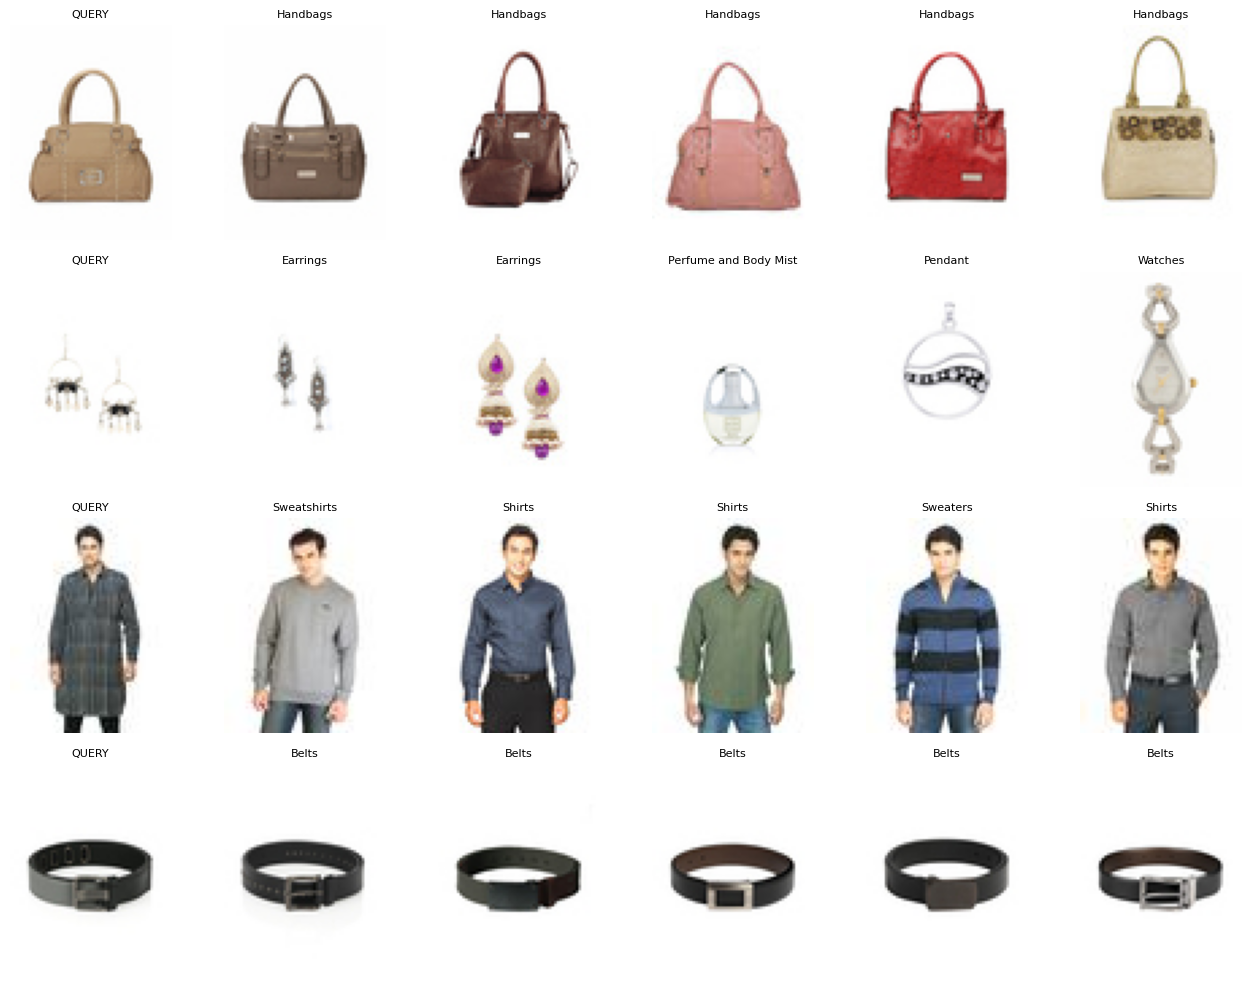

In [ ]:
def show_examples(emb, n_queries=4, k=5):
    emb = emb[test_idx]
    nn_model = NearestNeighbors(n_neighbors=k + 1, metric="cosine").fit(emb)
    fig, axes = plt.subplots(n_queries, k + 1, figsize=(2.2 * (k + 1), 2.5 * n_queries))
    for r, q in enumerate(np.random.choice(len(emb), n_queries, replace=False)):
        _, idx = nn_model.kneighbors(emb[q:q + 1])
        for c, j in enumerate(idx[0]):                              # first one is the query itself
            pid = ids[test_idx[j]]
            axes[r, c].imshow(Image.open(f"{DATA}/images/{pid}.jpg"))
            axes[r, c].axis("off")
            axes[r, c].set_title("QUERY" if c == 0 else df["articleType"][test_idx[j]], fontsize=8)
    plt.tight_layout(); plt.savefig("examples.png", dpi=110); plt.show()

show_examples(resnet_feats)

In [ ]:
from IPython.display import display, Image as IPImage

print("=== Results (held-out test set) ===")
display(results.style.format({f"Precision@{K}": "{:.4f}", f"MAP@{K}": "{:.4f}"})
        .highlight_max(subset=[f"Precision@{K}", f"MAP@{K}"], color="blue"))

=== Results (held-out test set) ===


,Method,Precision@10,MAP@10
0,Random,0.0565,0.0197
1,Autoencoder (from scratch),0.4334,0.3690
2,ResNet-50 (pretrained),0.5819,0.5316
